# Global Firepower 2026 — Exploratory Data Analysis & Business Insights

This notebook analyzes the eight **2026 analysis-ready datasets** produced by the data collection and preparation pipeline.

**Objective:** examine how defense spending, manpower, military technology, logistics, geography, and natural resources are associated with Global Firepower military-power measures.

> **Scope:** This analysis compares 145 countries using the 2026 Global Firepower dataset. It describes relationships and patterns between military-related variables; it does not establish that one factor causes another.

## 1. Load Analysis-Ready Datasets

The data-preparation notebook produces eight datasets, each covering the 145 countries in the project scope.

In [48]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_DIR = Path('.')

files = {
    'manpower': 'df_manpower_2026.pkl',
    'finance': 'df_finance_2026.pkl',
    'airforce': 'df_airforce_2026.pkl',
    'army': 'df_army_2026.pkl',
    'navy': 'df_navy_2026.pkl',
    'logistics': 'df_logistics_2026.pkl',
    'geography': 'df_geography_2026.pkl',
    'resources': 'df_nat_resources_2026.pkl'
}

dfs = {
    name: pd.read_pickle(DATA_DIR / filename)
    for name, filename in files.items()
}

df_manpower_2026 = dfs['manpower']
df_finance_2026 = dfs['finance']
df_airforce_2026 = dfs['airforce']
df_army_2026 = dfs['army']
df_navy_2026 = dfs['navy']
df_logistics_2026 = dfs['logistics']
df_geography_2026 = dfs['geography']
df_nat_resources_2026 = dfs['resources']

print('Datasets loaded successfully.')

Datasets loaded successfully.


In [49]:
dataset_summary = pd.DataFrame({
    'dataset': list(dfs.keys()),
    'rows': [df.shape[0] for df in dfs.values()],
    'columns': [df.shape[1] for df in dfs.values()],
    'missing_cells': [int(df.isna().sum().sum()) for df in dfs.values()]
})
dataset_summary

,dataset,rows,columns,missing_cells
0,manpower,145,9,0
1,finance,145,6,0
2,airforce,145,10,0
3,army,145,7,0
4,navy,145,12,94
5,logistics,145,7,0
6,geography,145,6,0
7,resources,145,11,0


## 2. Data Quality and Coverage

Each dataset should contain the same 145-country project scope. Missing values are retained when the source does not provide a value rather than being automatically converted to zero.

In [50]:
coverage_check = pd.DataFrame({
    name: [df['country'].nunique(), df['country'].duplicated().sum()]
    for name, df in dfs.items()
}, index=['unique_countries', 'duplicate_country_rows']).T
coverage_check

,unique_countries,duplicate_country_rows
manpower,145,0
finance,145,0
airforce,145,0
army,145,0
navy,145,0
logistics,145,0
geography,145,0
resources,145,0


### Navy Fleet Tonnage Coverage

Fleet tonnage is a source-limited variable. The data-preparation stage found values for **51 of 145 countries**; the remaining **94 countries** have missing (`NaN`) values because the source does not provide fleet-tonnage data for them.

Analyses using fleet tonnage must therefore use only observations with an available value. The Navy dataset itself retains all 145 countries.

In [51]:
navy_tonnage_coverage = df_navy_2026['navy_force_by_tonnage'].notna().sum()
print(f'Fleet tonnage available: {navy_tonnage_coverage} of {len(df_navy_2026)} countries')

Fleet tonnage available: 51 of 145 countries


## 3. Build the Master Analytical Dataset

The country-level datasets are merged using `country`. The manpower dataset supplies the overall Global Firepower rank and Power Index used as the primary military-power outcomes.

In [52]:
master = df_manpower_2026.copy().rename(
    columns={'rank': 'overall_power_rank'}
)

merge_sources = {
    'finance': df_finance_2026,
    'airforce': df_airforce_2026,
    'army': df_army_2026,
    'navy': df_navy_2026,
    'logistics': df_logistics_2026,
    'geography': df_geography_2026,
    'resources': df_nat_resources_2026
}

for name, df in merge_sources.items():
    add = df.drop(columns=['rank'], errors='ignore')
    master = master.merge(add, on='country', how='left', validate='one_to_one')

print('Master shape:', master.shape)
print('Unique countries:', master['country'].nunique())

Master shape: (145, 54)
Unique countries: 145


In [53]:
master.head()

,overall_power_rank,country,power_index,available_manpower_million,paramilitary_million,labor_force_strength_million,active_manpower_million,active_reserves_million,fit_for_service_million,annual_defense_budget,external_debt,purchasing_power_parity,foreign_exchange_reserves,total_aircraft,fighter_fleet,attack_fleet,transport_fleet,trainer_fleet,attack_helicopter_fleet,tanker_fleet,helicopter_fleet,tank_fleet_strength,armored_fighting_vehicle,self_propelled_artillery,towed_artillery,rocket_projectors,naval_fleet_strength,navy_force_by_tonnage,aircraft_carriers,helicopter_carriers,submarines,destroyers,frigates,corvettes,coastal_patrol,mine_warfare,serviceable_airports,major_ports_terminals,merchant_marine_strength,railway_coverage,roadway_coverage,land_area_km2,coastline_coverage,border_coverage,waterway_coverage,oil_production,oil_consumption,oil_reserves,natural_gas_production,natural_gas_consumption,natural_gas_reserves,coal_production,coal_consumption,coal_reserves
0,1,United States,0.074,150.464,0.000,174.174,1.333,0.800,124.817,831.500,"24,538.900",25.680,910.040,13032,1791,926,917,2610,1024,610,5913,4666,409660,1521,1878,1731,465,"8,265,799.000",11,9,66,83,0,27,0,4,16116,666,3533,293564,6586610,9833517,19924,12002,41009,20.950,20.310,38.210,1.030,0.910,13.400,534.230,495.160,247.880
1,2,Russia,0.079,69.002,0.250,72.517,1.320,2.000,46.189,212.640,226.480,6.090,597.220,4237,861,698,458,530,556,18,1643,5630,126512,3603,5920,2486,747,"1,426,539.000",1,0,66,13,12,79,70,45,905,67,2910,85494,1283387,17098242,37653,22407,102000,10.880,3.860,80.000,0.620,0.470,47.800,531.130,290.760,162.170
2,3,China,0.092,764.123,0.625,773.880,2.035,0.510,626.864,303.000,488.110,33.600,"3,456.000",3529,1443,371,287,401,281,9,1007,5870,152040,2940,1400,2770,841,"3,192,411.000",3,4,61,53,46,50,150,36,552,66,8314,150000,5200000,9596960,14500,22457,27700,4.980,16.190,26.020,0.230,0.370,6.650,"4,805.000","5,191.000",157.040
3,4,India,0.135,662.290,2.527,607.691,1.431,1.000,522.787,109.000,212.730,14.240,643.040,2183,476,124,277,334,79,6,594,3913,163554,100,5640,300,343,"631,989.000",2,0,18,13,18,21,146,0,315,56,1859,65554,6371847,3287263,7000,13888,14500,0.820,5.270,4.610,0.030,0.060,1.380,"1,020.000","1,262.000",127.730
4,5,South Korea,0.164,26.041,0.120,29.713,0.450,3.100,21.354,44.800,553.870,2.610,418.220,1540,242,98,40,335,113,4,827,1831,117460,2780,5800,525,215,"427,946.000",0,2,22,14,18,3,96,14,92,15,2149,3979,100428,99720,2413,237,1600,0.040,2.540,0.000,0.000,0.060,0.010,16.080,136.820,0.330


## 4. Feature Engineering for Analysis

The following analytical features are created in this notebook. They are derived from the analysis-ready source variables and are not presented as additional source data.

In [56]:
# Defense-budget rank and rank gap
master['budget_rank'] = master['annual_defense_budget'].rank(
    ascending=False, method='dense'
)
master['budget_power_rank_gap'] = (
    master['budget_rank'] - master['overall_power_rank']
)

# Aircraft intensity: aircraft available per 100,000 active personnel
active_personnel = master['active_manpower_million'] * 1_000_000
master['aircraft_per_100k_personnel'] = np.where(
    active_personnel > 0,
    master['total_aircraft'] / active_personnel * 100_000,
    np.nan
)

# Equal-weight max-normalized logistics index
logistics_cols = [
    'serviceable_airports', 'major_ports_terminals',
    'railway_coverage', 'roadway_coverage'
]
for col in logistics_cols:
    master[f'{col}_norm'] = master[col] / master[col].max()
master['logistics_score'] = master[[f'{c}_norm' for c in logistics_cols]].mean(axis=1)

# Equal-weight max-normalized geography index
geo_cols = ['land_area_km2', 'coastline_coverage', 'border_coverage', 'waterway_coverage']
for col in geo_cols:
    master[f'{col}_norm'] = master[col] / master[col].max()
master['geography_score'] = master[[f'{c}_norm' for c in geo_cols]].mean(axis=1)

# Transparent natural-resource index using reserves of oil, natural gas and coal
resource_cols = [
    'oil_reserves',
    'natural_gas_reserves',
    'coal_reserves'
]
for col in resource_cols:
    master[f'{col}_norm'] = master[col] / master[col].max()
master['resource_score'] = master[[f'{c}_norm' for c in resource_cols]].mean(axis=1)

master[['country', 'overall_power_rank', 'power_index',
        'budget_power_rank_gap', 'aircraft_per_100k_personnel',
        'logistics_score', 'geography_score', 'resource_score']].head()

,country,overall_power_rank,power_index,budget_power_rank_gap,aircraft_per_100k_personnel,logistics_score,geography_score,resource_score
0,United States,1,0.074,0.000,977.644,1.000,0.403,0.469
1,Russia,2,0.079,1.000,320.985,0.161,0.796,0.639
2,China,3,0.092,-1.000,173.415,0.358,0.476,0.286
3,India,4,0.135,1.000,152.551,0.324,0.247,0.186
4,South Korea,5,0.164,10.000,342.222,0.014,0.011,0.001


## 5. Exploratory Overview

Before answering the business questions, we inspect distributions and relationships among the primary outcome and selected explanatory variables.

In [57]:
eda_cols = [
    'power_index', 'annual_defense_budget', 'active_manpower_million',
    'total_aircraft', 'logistics_score', 'geography_score', 'resource_score'
]
master[eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
power_index,145.000,1.643,1.135,0.074,0.652,1.543,2.397,5.799
annual_defense_budget,145.000,19.732,76.720,0.020,0.680,2.490,9.170,831.500
active_manpower_million,145.000,0.162,0.297,0.000,0.022,0.051,0.160,2.035
total_aircraft,145.000,359.041,"1,191.811",0.000,25.000,99.000,271.000,"13,032.000"
logistics_score,145.000,0.032,0.096,0.000,0.004,0.008,0.020,1.000
geography_score,145.000,0.070,0.102,0.000,0.021,0.040,0.079,0.796
resource_score,145.000,0.033,0.095,0.000,0.000,0.002,0.010,0.639


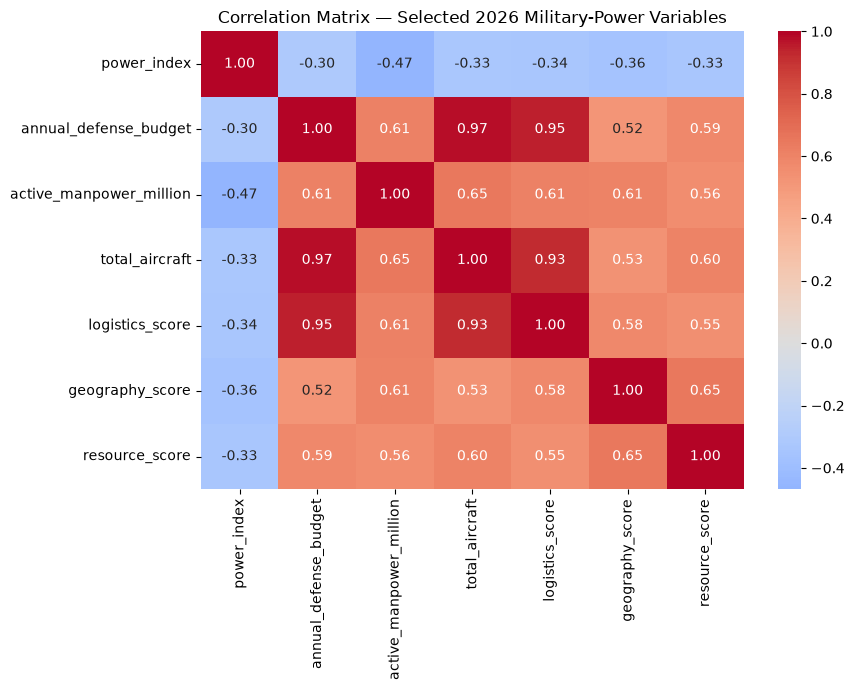

In [58]:
corr_cols = eda_cols
corr = master[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Selected 2026 Military-Power Variables')
plt.tight_layout()
plt.show()

## Business Question 1 — How is Defense Spending Associated with Military Power?

**Metric:** annual defense budget and Power Index.

**Method:** compare defense spending with the Power Index using a scatter plot and Pearson correlation. Because defense budgets are highly skewed, the x-axis uses a logarithmic scale.

**Interpretation note:** A negative correlation is directionally consistent with higher spending being associated with a lower (stronger) Power Index, but it does not establish causation.

Pearson correlation (defense budget vs Power Index): -0.302


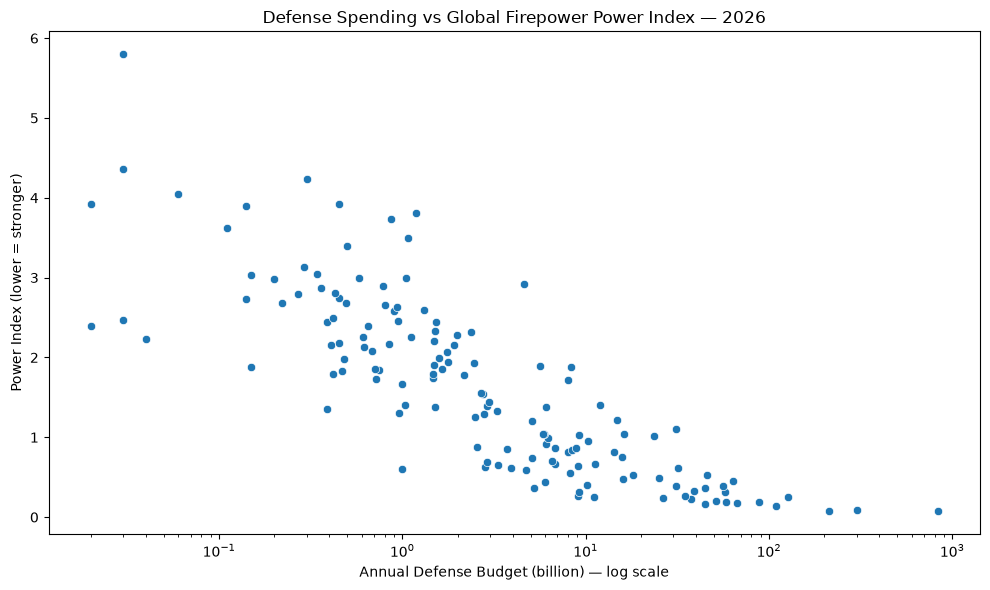

In [59]:
q1 = master[['country', 'annual_defense_budget', 'power_index', 'overall_power_rank']].dropna().copy()
q1_corr = q1['annual_defense_budget'].corr(q1['power_index'])
print(f'Pearson correlation (defense budget vs Power Index): {q1_corr:.3f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=q1, x='annual_defense_budget', y='power_index')
plt.xscale('log')
plt.xlabel('Annual Defense Budget (billion) — log scale')
plt.ylabel('Power Index (lower = stronger)')
plt.title('Defense Spending vs Global Firepower Power Index — 2026')
plt.tight_layout()
plt.show()

In [60]:
q1.sort_values('annual_defense_budget', ascending=False).head(15)

,country,annual_defense_budget,power_index,overall_power_rank
0,United States,831.500,0.074,1
2,China,303.000,0.092,3
1,Russia,212.640,0.079,2
11,Germany,127.400,0.246,12
3,India,109.000,0.135,4
7,United Kingdom,88.530,0.188,8
5,France,67.230,0.180,6
24,Saudi Arabia,63.990,0.447,25
6,Japan,58.000,0.188,7
16,Australia,57.350,0.321,17


## Business Question 2 — Where Does Military-Power Rank Differ from Defense-Spending Rank?

`budget_power_rank_gap = budget_rank - overall_power_rank`

- Positive values: the country's numerical power rank is stronger than its budget rank would suggest.
- Negative values: the country's budget rank is stronger than its numerical power rank.

In [61]:
q2 = master[['country', 'annual_defense_budget', 'budget_rank',
              'overall_power_rank', 'budget_power_rank_gap']].copy()
q2 = q2.sort_values('budget_power_rank_gap', ascending=False)
q2.head(15)

,country,annual_defense_budget,budget_rank,overall_power_rank,budget_power_rank_gap
31,Argentina,0.990,94.000,32,62.000
65,Sudan,0.390,119.000,66,53.000
86,Syria,0.150,127.000,87,40.000
80,Paraguay,0.420,117.000,81,36.000
18,Egypt,5.190,55.000,19,36.000
81,Bolivia,0.470,114.000,82,32.000
34,Myanmar,2.820,66.000,35,31.000
63,Democratic Republic of the Congo,0.960,95.000,64,31.000
101,Latvia,0.040,131.000,102,29.000
76,Albania,0.720,104.000,77,27.000


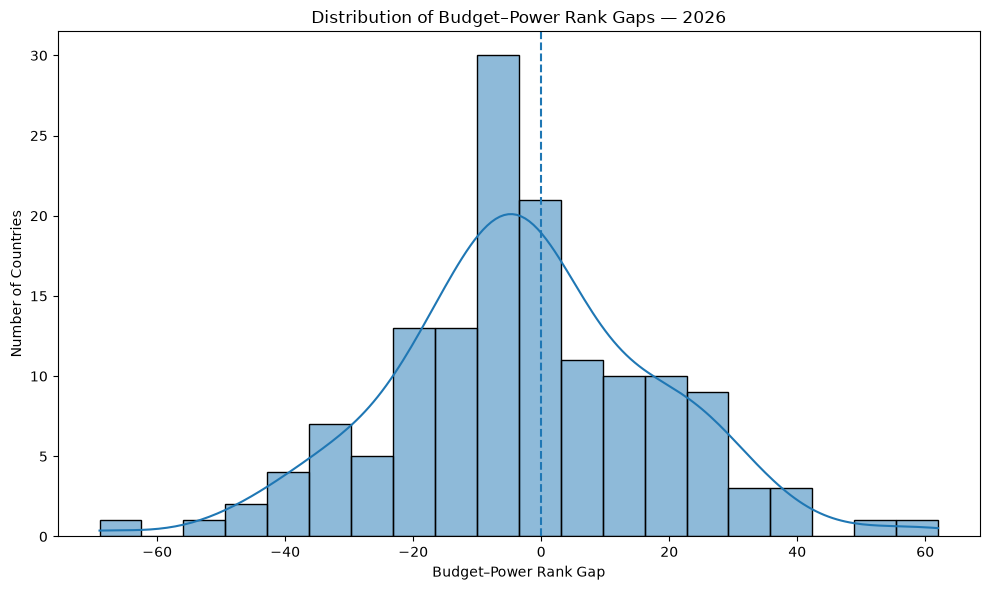

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(q2['budget_power_rank_gap'], bins=20, kde=True)
plt.axvline(0, linestyle='--')
plt.xlabel('Budget–Power Rank Gap')
plt.ylabel('Number of Countries')
plt.title('Distribution of Budget–Power Rank Gaps — 2026')
plt.tight_layout()
plt.show()

## Business Question 3 — How Does Military Technology Intensity Relate to Military Power?

**Metric:** aircraft per 100,000 active military personnel.

This is an intensity measure rather than a direct measure of technological quality. It helps compare the scale of air assets relative to active personnel across countries.

Pearson correlation (aircraft intensity vs Power Index): -0.352


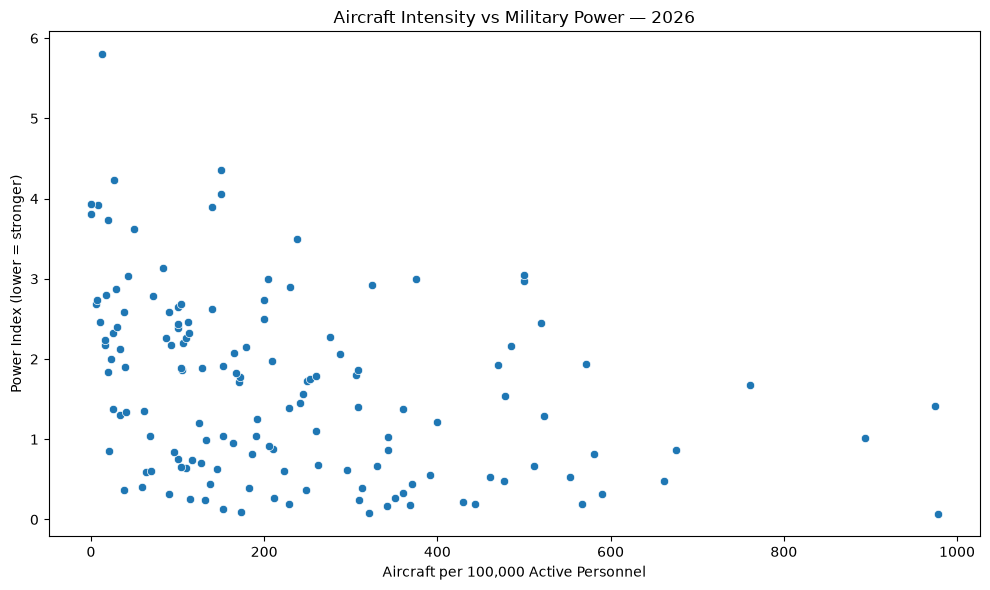

In [63]:
q3 = master[['country', 'active_manpower_million', 'total_aircraft',
              'aircraft_per_100k_personnel', 'power_index', 'overall_power_rank']].dropna().copy()
q3_corr = q3['aircraft_per_100k_personnel'].corr(q3['power_index'])
print(f'Pearson correlation (aircraft intensity vs Power Index): {q3_corr:.3f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=q3, x='aircraft_per_100k_personnel', y='power_index')
plt.xlabel('Aircraft per 100,000 Active Personnel')
plt.ylabel('Power Index (lower = stronger)')
plt.title('Aircraft Intensity vs Military Power — 2026')
plt.tight_layout()
plt.show()

In [64]:
q3.sort_values('aircraft_per_100k_personnel', ascending=False).head(15)

,country,active_manpower_million,total_aircraft,aircraft_per_100k_personnel,power_index,overall_power_rank
0,United States,1.333,13032,977.644,0.074,1
70,Qatar,0.027,263,974.074,1.410,71
53,United Arab Emirates,0.065,581,893.846,1.019,54
74,Bahrain,0.018,137,761.111,1.673,75
47,Finland,0.024,162,675.000,0.867,48
25,Sweden,0.026,172,661.538,0.483,26
16,Australia,0.059,348,589.831,0.321,17
44,Denmark,0.021,122,580.952,0.820,45
90,Slovenia,0.007,40,571.429,1.940,91
6,Japan,0.252,1429,567.063,0.188,7


## Business Question 4 — How Does Logistics Infrastructure Relate to Military Power?

**Logistics score:** equal-weight mean of max-normalized serviceable airports, major ports/terminals, railway length, and roadway length.

This is a project-defined index intended for comparative analysis; it is not an official Global Firepower score.

Pearson correlation (logistics score vs Power Index): -0.341


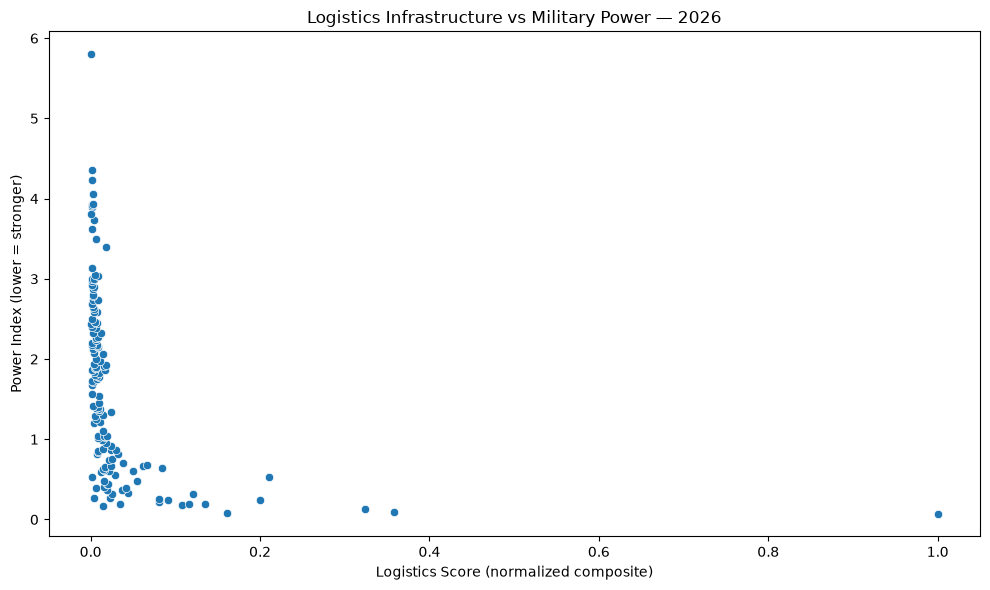

In [35]:
q4 = master[['country', 'logistics_score', 'total_aircraft',
              'power_index', 'overall_power_rank']].dropna().copy()
q4_corr = q4['logistics_score'].corr(q4['power_index'])
print(f'Pearson correlation (logistics score vs Power Index): {q4_corr:.3f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=q4, x='logistics_score', y='power_index')
plt.xlabel('Logistics Score (normalized composite)')
plt.ylabel('Power Index (lower = stronger)')
plt.title('Logistics Infrastructure vs Military Power — 2026')
plt.tight_layout()
plt.show()

In [36]:
q4.sort_values('logistics_score', ascending=False).head(15)

,country,logistics_score,total_aircraft,power_index,overall_power_rank
0,United States,1.000,13032,0.074,1
2,China,0.358,3529,0.092,3
3,India,0.324,2183,0.135,4
27,Canada,0.210,354,0.527,28
10,Brazil,0.200,495,0.237,11
1,Russia,0.161,4237,0.079,2
6,Japan,0.135,1429,0.188,7
16,Australia,0.121,348,0.321,17
7,United Kingdom,0.116,625,0.188,8
5,France,0.107,974,0.180,6


## Business Question 5 — How Are Geography and Natural-Resource Endowments Associated with Military Power?

Two transparent project-defined indices are used:

- **Geography score:** equal-weight mean of normalized land area, coastline, land borders, and waterways.
- **Resource score:** equal-weight mean of normalized oil, natural-gas, and coal reserves.

These scores summarize the available indicators for comparison; they should not be interpreted as official measures of military capability.

In [65]:
q5 = master[['country', 'geography_score', 'resource_score',
              'power_index', 'overall_power_rank']].dropna().copy()

geo_corr = q5['geography_score'].corr(q5['power_index'])
resource_corr = q5['resource_score'].corr(q5['power_index'])
print(f'Pearson correlation (geography score vs Power Index): {geo_corr:.3f}')
print(f'Pearson correlation (resource score vs Power Index): {resource_corr:.3f}')

Pearson correlation (geography score vs Power Index): -0.362
Pearson correlation (resource score vs Power Index): -0.334


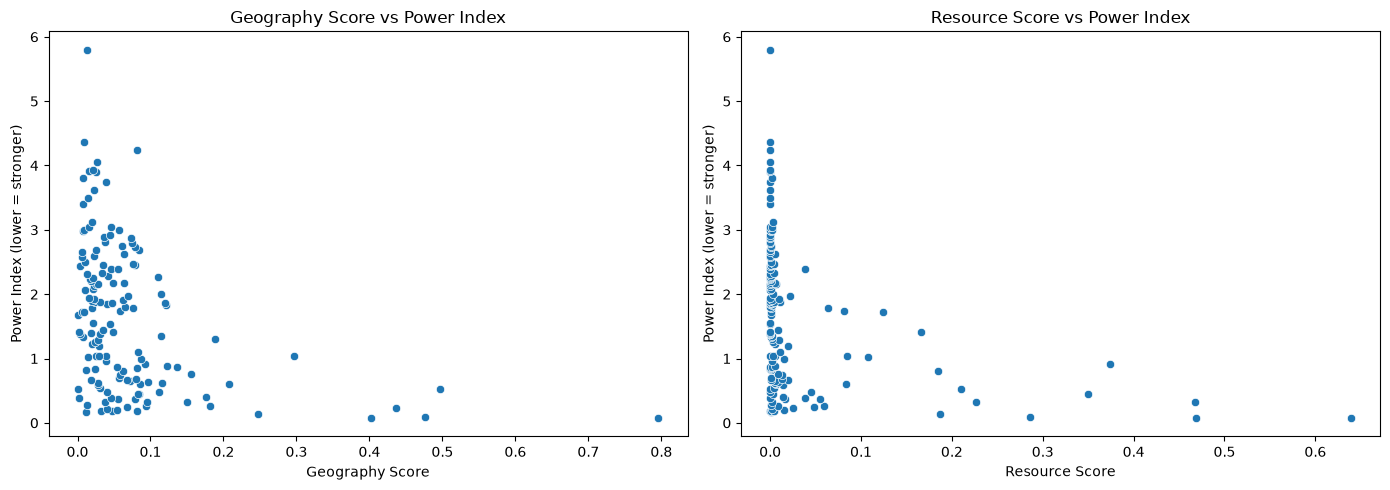

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=q5, x='geography_score', y='power_index', ax=axes[0])
axes[0].set_title('Geography Score vs Power Index')
axes[0].set_xlabel('Geography Score')
axes[0].set_ylabel('Power Index (lower = stronger)')

sns.scatterplot(data=q5, x='resource_score', y='power_index', ax=axes[1])
axes[1].set_title('Resource Score vs Power Index')
axes[1].set_xlabel('Resource Score')
axes[1].set_ylabel('Power Index (lower = stronger)')

plt.tight_layout()
plt.show()

In [67]:
q5.sort_values('geography_score', ascending=False).head(10), q5.sort_values('resource_score', ascending=False).head(10)

(                             country  geography_score  resource_score  \
 1                             Russia            0.796           0.639   
 27                            Canada            0.497           0.210   
 2                              China            0.476           0.286   
 10                            Brazil            0.436           0.025   
 0                      United States            0.403           0.469   
 57                        Kazakhstan            0.296           0.084   
 3                              India            0.247           0.186   
 31                         Argentina            0.207           0.007   
 63  Democratic Republic of the Congo            0.188           0.002   
 12                         Indonesia            0.181           0.060   
 
     power_index  overall_power_rank  
 1         0.079                   2  
 27        0.527                  28  
 2         0.092                   3  
 10        0.237            

## 7. Limitations

- This analysis uses only 2026 data.
- Global Firepower measures military power using its own methodology.
- Some scores were created specifically for this project.
- Navy fleet-tonnage data is available for only 51 countries.
- Correlation shows relationships but does not prove cause and effect.
- Very large values can influence some results.

## 8. Conclusion

This notebook analyzes the cleaned 2026 Global Firepower data for 145 countries. It uses statistics, charts, correlation analysis, and calculated features to examine how defense spending, manpower, military assets, logistics, geography, and natural resources are related to military-power measures.